In [3]:
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
import torch; from torch import nn; from d2l import torch as d2l
if os.path.basename(os.getcwd()) == 'notes': os.chdir('..')
print('工作目录:', os.getcwd())

工作目录: d:\github\prediction


In [4]:
# ============================================================
# 从 NetCDF 读取 #0 站点 (1141A 普陀) → 80/15/5 分割 → 预处理 → MLP 训练
# 先分割再插值, 杜绝边界数据泄漏; pm_ave 保持原始量纲
# ============================================================
import netCDF4 as nc

def load_station(nc_path, idx=0):
    """从 NetCDF 读取指定站点, 转为带 datetime 索引的 DataFrame"""
    f = nc.Dataset(nc_path)
    t = f.variables['time'][:]
    dt = pd.Timestamp(f.variables['time'].units.split('since ')[1]) + pd.to_timedelta(t, unit='h')
    pm25 = f.variables['PM2.5'][:, idx]
    f.close()
    df = pd.DataFrame({'PM_Jingan': pm25, 'PM_US Post': pm25, 'PM_Xuhui': pm25}, index=dt)
    df.index.name = 'datetime'
    return df.resample('1h').first()

def split_and_preprocess(df, ratios=(0.80, 0.15, 0.05)):
    """分割 → 各子集独立预处理 → 返回 train/val/test"""
    n = len(df); n1 = int(n * ratios[0]); n2 = int(n * sum(ratios[:2]))
    subs = []
    for raw in [df.iloc[:n1], df.iloc[n1:n2], df.iloc[n2:]]:
        d = raw.copy()
        d['pm_ave'] = d[['PM_Jingan','PM_US Post','PM_Xuhui']].mean(axis=1)
        d['pm_ave'] = d['pm_ave'].interpolate(method='time', limit=168).ffill().bfill()
        subs.append(d)
    return subs

df_raw = load_station('data3/dataset_yrd.nc', idx=0)
df_tr, df_va, df_te = split_and_preprocess(df_raw)
print(f'训练 {len(df_tr)} | 验证 {len(df_va)} | 测试 {len(df_te)}')

# pm_ave 提取 + 标准化 (用训练集统计量)
x_tr = torch.tensor(df_tr['pm_ave'].values, dtype=torch.float32)
x_va = torch.tensor(df_va['pm_ave'].values, dtype=torch.float32)
x_te = torch.tensor(df_te['pm_ave'].values, dtype=torch.float32)
mean, std = x_tr.mean(), x_tr.std()
x_tr, x_va, x_te = (x_tr - mean) / std, (x_va - mean) / std, (x_te - mean) / std

# 自回归特征: 过去 tau 步预测下一步
tau = 24
def make_feats(x, tau):
    feats = torch.zeros((len(x) - tau, tau))
    for i in range(tau): feats[:, i] = x[i:len(x)-tau+i]
    return feats, x[tau:].reshape((-1, 1))

ftr_tr, lab_tr = make_feats(x_tr, tau)
ftr_va, lab_va = make_feats(x_va, tau)
train_iter = d2l.load_array((ftr_tr, lab_tr), 16, is_train=True)
val_iter   = d2l.load_array((ftr_va, lab_va), 16, is_train=False)

# MLP: Linear(tau,128) → ReLU → Linear(128,1)
def get_net():
    net = nn.Sequential(nn.Linear(tau, 128), nn.ReLU(), nn.Linear(128, 1))
    net.apply(lambda m: nn.init.xavier_uniform_(m.weight) if type(m)==nn.Linear else None)
    return net

loss = nn.MSELoss(reduction='none')
def train(net, tr_it, va_it, loss, epochs, lr, wd=0.002):
    opt = torch.optim.Adam(net.parameters(), lr)
    for ep in range(epochs):
        net.train()
        for X, y in tr_it:
            opt.zero_grad()
            l = loss(net(X), y); l2 = sum((p**2).sum() for p in net.parameters())
            (l.sum() + wd * l2).backward(); opt.step()
        print(f'epoch {ep+1}, train {d2l.evaluate_loss(net,tr_it,loss):.4f}, val {d2l.evaluate_loss(net,va_it,loss):.4f}')

net = get_net()
train(net, train_iter, val_iter, loss, 10, 0.01)

训练 56102 | 验证 10519 | 测试 3507
epoch 1, train 0.0704, val 0.0418
epoch 2, train 0.0558, val 0.0398
epoch 3, train 0.0576, val 0.0467
epoch 4, train 0.0739, val 0.0497
epoch 5, train 0.0542, val 0.0412
epoch 6, train 0.0728, val 0.0527
epoch 7, train 0.0796, val 0.0828
epoch 8, train 0.0988, val 0.1167
epoch 9, train 0.0558, val 0.0456
epoch 10, train 0.0587, val 0.0519


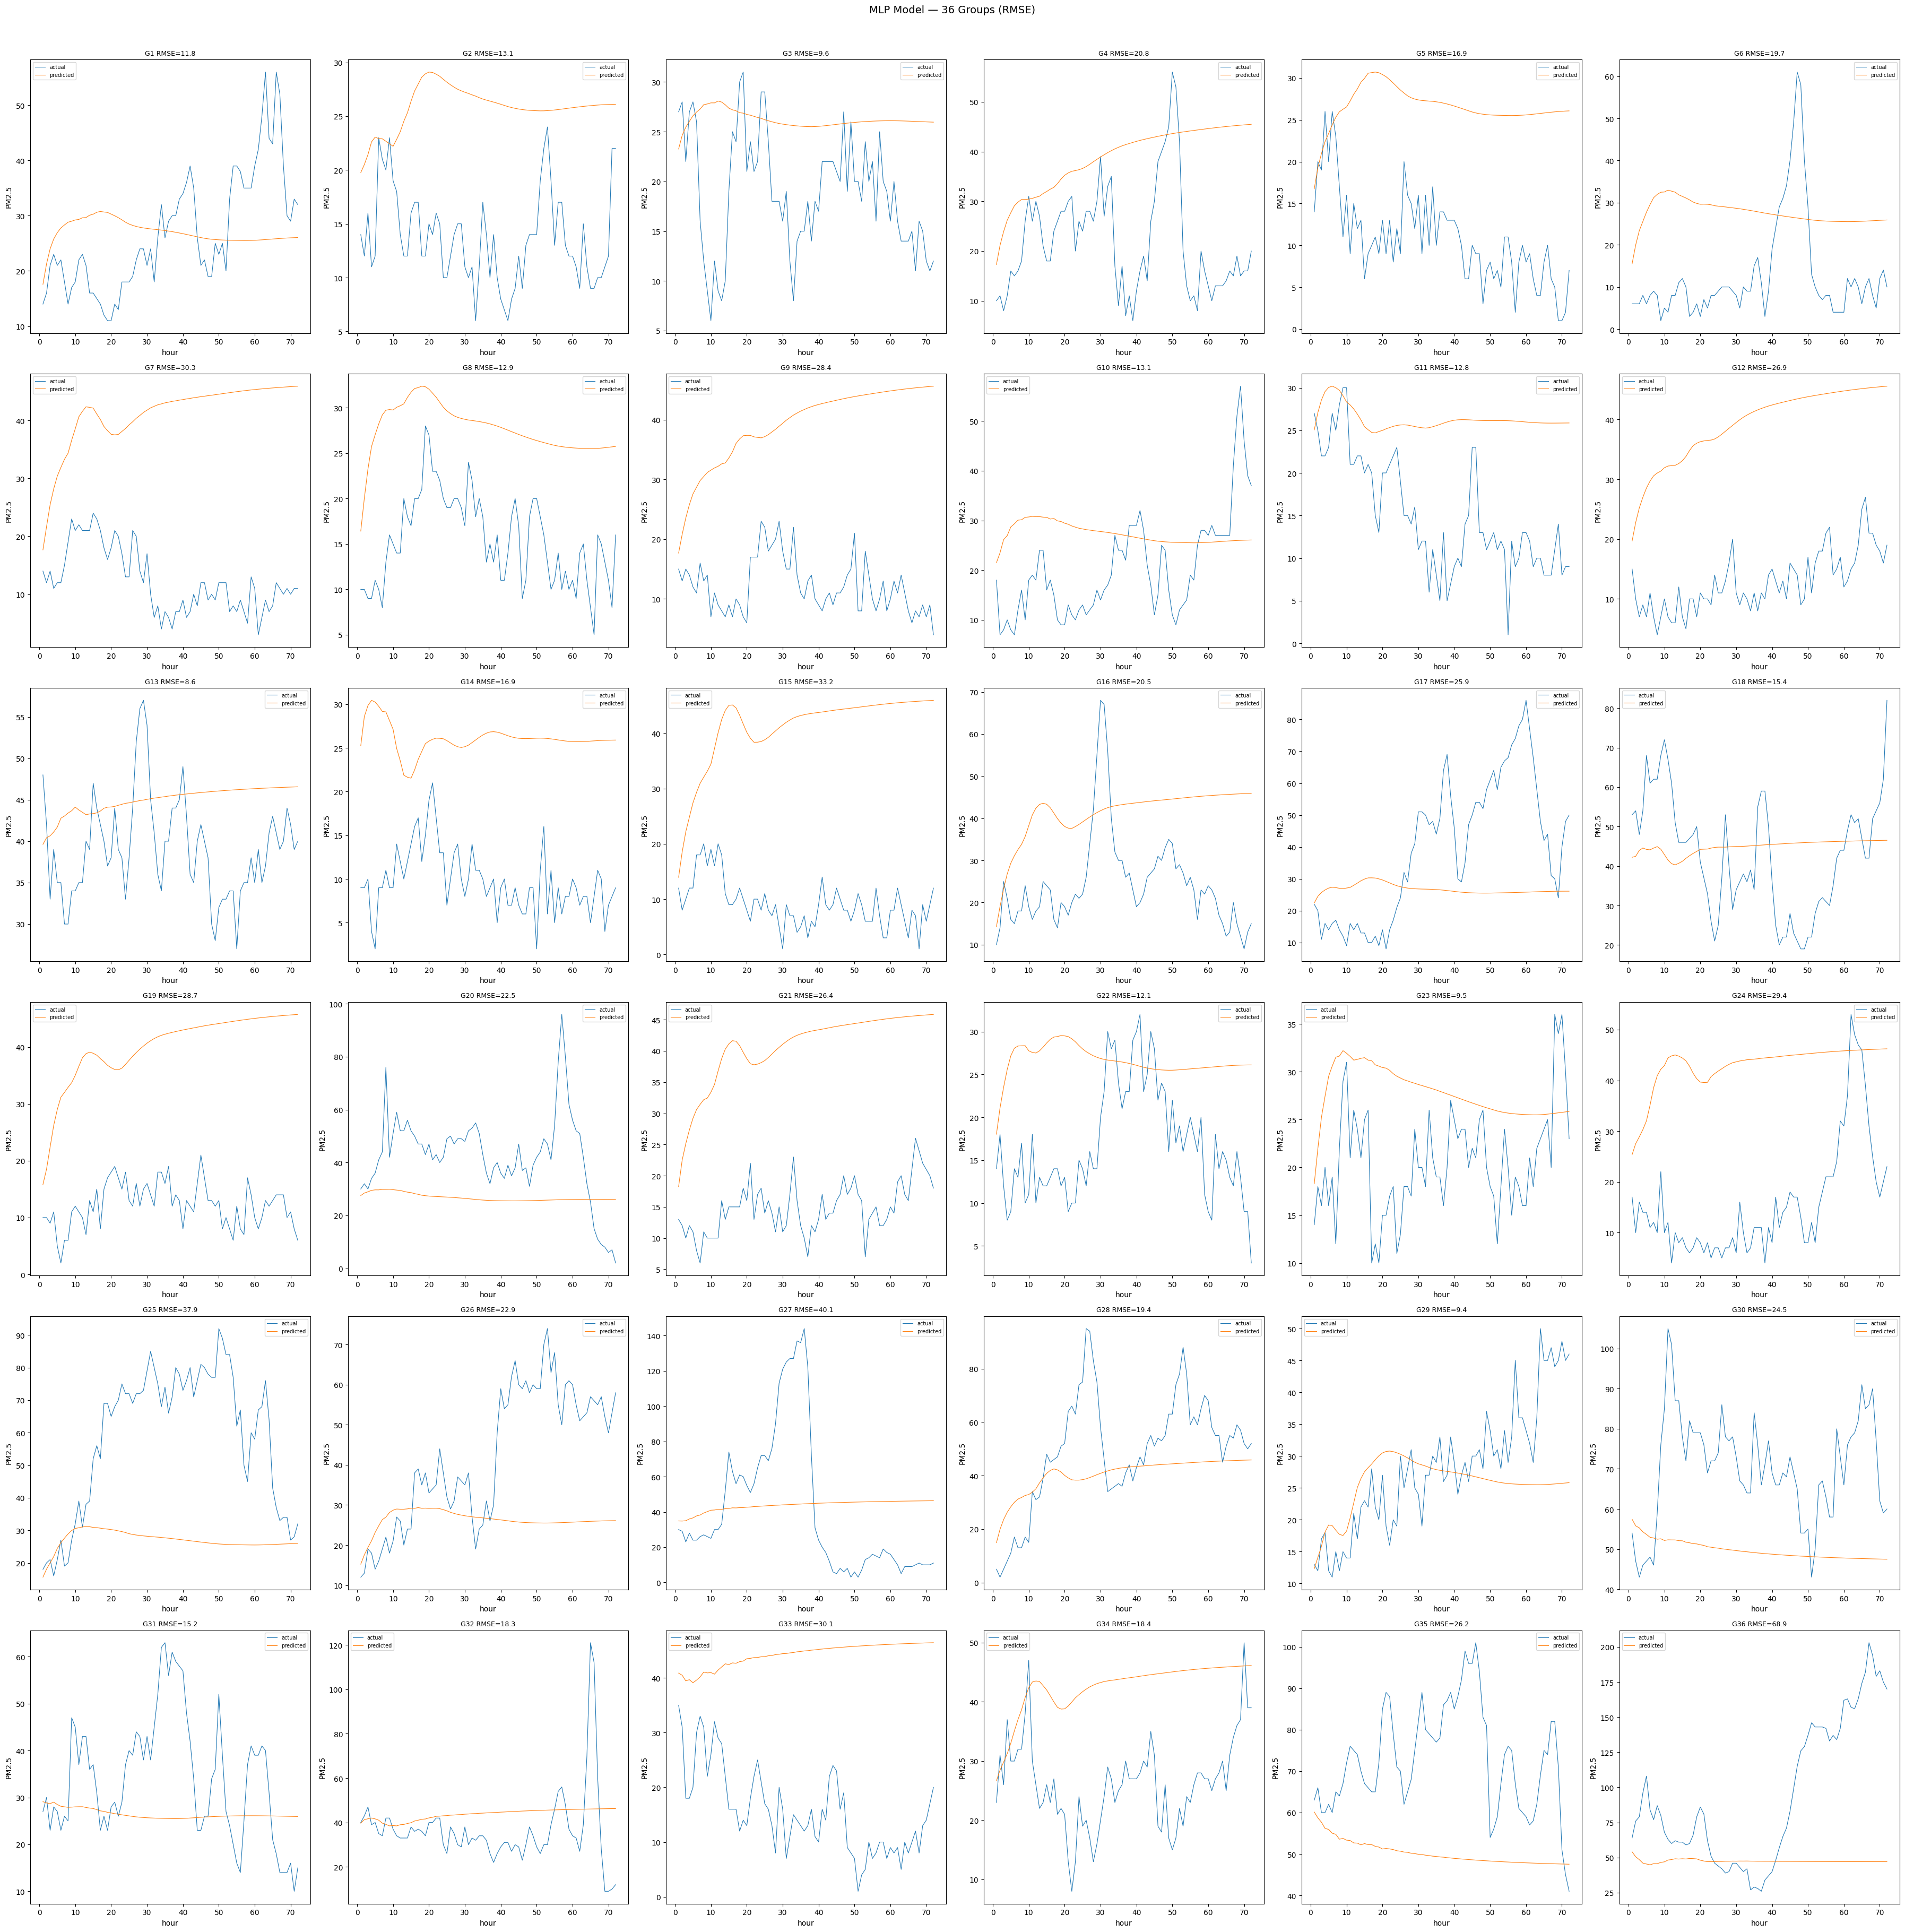


=== 36 组 RMSE 汇总 ===
  G 1: 11.76
  G 2: 13.14
  G 3: 9.65
  G 4: 20.78
  G 5: 16.91
  G 6: 19.68
  G 7: 30.27
  G 8: 12.86
  G 9: 28.36
  G10: 13.06
  G11: 12.76
  G12: 26.93
  G13: 8.63
  G14: 16.89
  G15: 33.23
  G16: 20.51
  G17: 25.92
  G18: 15.36
  G19: 28.71
  G20: 22.47
  G21: 26.41
  G22: 12.09
  G23: 9.51
  G24: 29.39
  G25: 37.89
  G26: 22.93
  G27: 40.08
  G28: 19.35
  G29: 9.45
  G30: 24.53
  G31: 15.20
  G32: 18.33
  G33: 30.11
  G34: 18.41
  G35: 26.16
  G36: 68.86

平均 RMSE = 22.13


In [5]:
# ============================================================
# 36 组评估: 每组 24h 上下文 + 72h 递归预测, RMSE (ug/m3)
# ============================================================
N_GROUPS, N_CTX, N_PRED = 36, 24, 72
STRIDE = (len(df_te) - N_CTX - N_PRED) // (N_GROUPS - 1)

rmses = []
fig, axes = plt.subplots(6, 6, figsize=(36, 36)); axes = axes.flatten()
for g in range(N_GROUPS):
    s = g * STRIDE
    series = np.zeros(N_CTX + N_PRED)
    series[:N_CTX] = x_te[s:s+N_CTX].numpy()
    with torch.no_grad():
        for i in range(N_PRED):
            w = torch.tensor(series[i:i+tau], dtype=torch.float32)
            series[N_CTX+i] = net(w.reshape(1,-1)).item()
    preds = series[N_CTX:] * std.item() + mean.item()  # 反标准化
    actual = df_te['pm_ave'].values[s+N_CTX:s+N_CTX+N_PRED]
    rmse = np.sqrt(((preds - actual) ** 2).mean())
    rmses.append(rmse)
    ax = axes[g]; h = np.arange(1, N_PRED+1)
    ax.plot(h, actual, lw=0.8, label='actual')
    ax.plot(h, preds, lw=0.8, label='predicted')
    ax.set_title(f'G{g+1} RMSE={rmse:.1f}', fontsize=9)
    ax.legend(fontsize=7); ax.set_xlabel('hour'); ax.set_ylabel('PM2.5')
plt.suptitle(f'MLP Model — {N_GROUPS} Groups (RMSE)', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()
print(f'\n=== {N_GROUPS} 组 RMSE 汇总 ===')
for g, r in enumerate(rmses): print(f'  G{g+1:2d}: {r:.2f}')
print(f'\n平均 RMSE = {np.mean(rmses):.2f}')